# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [8]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2399s 14us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

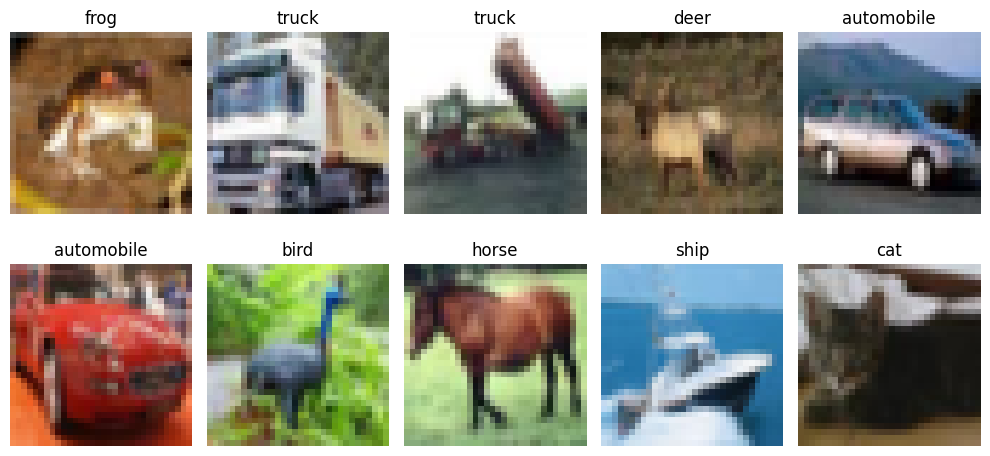

In [9]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [10]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [11]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.2674 - loss: 2.0071 - val_accuracy: 0.3230 - val_loss: 1.8313
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3254 - loss: 1.8519 - val_accuracy: 0.3796 - val_loss: 1.7447
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3420 - loss: 1.8033 - val_accuracy: 0.3784 - val_loss: 1.7247
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3542 - loss: 1.7734 - val_accuracy: 0.3824 - val_loss: 1.7424
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3611 - loss: 1.7483 - val_accuracy: 0.3974 - val_loss: 1.6879
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3674 - loss: 1.7370 - val_accuracy: 0.4108 - val_loss: 1.6808
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3742 - loss: 1.7205 - val_accuracy: 0.3950 - val_loss: 1.6977
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3800 - loss: 1.7032 - 

In [12]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4208 - loss: 1.6477
ANN Test Accuracy: 0.42080000042915344


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [13]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 126ms/step - accuracy: 0.4773 - loss: 1.4754 - val_accuracy: 0.5520 - val_loss: 1.2618
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.6159 - loss: 1.1016 - val_accuracy: 0.5784 - val_loss: 1.2147
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 128ms/step - accuracy: 0.6756 - loss: 0.9355 - val_accuracy: 0.6920 - val_loss: 0.8580
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 129ms/step - accuracy: 0.7153 - loss: 0.8161 - val_accuracy: 0.5540 - val_loss: 1.4933
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.7437 - loss: 0.7292 - val_accuracy: 0.6920 - val_loss: 0.8971
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7735 - loss: 0.6471 - val_accuracy: 0.7074 - val_loss: 0.8630
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 126ms/step - accuracy: 0.7921 - loss: 0.5845 - val_accuracy: 0.7098 - val_loss: 0.8899
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 128ms/step - accuracy: 0.8160 - loss

In [14]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6849 - loss: 1.0804
CNN Test Accuracy: 0.6848999857902527


## 📈 Compare Learning Curves

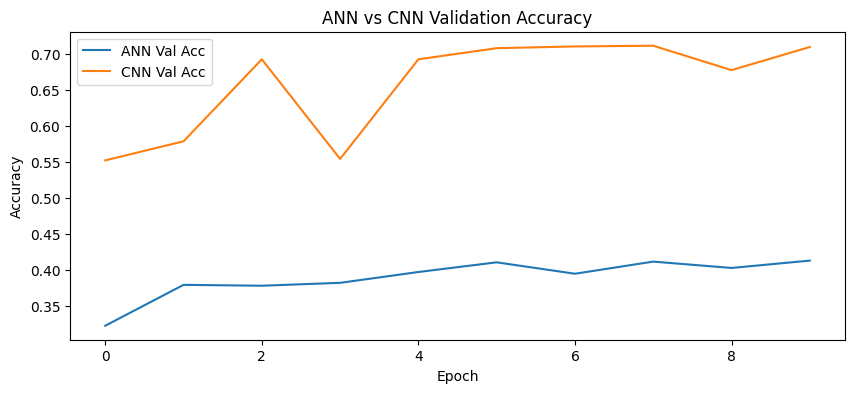

In [15]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [38]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [17]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4208
1,CNN,0.6849


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# **1. Increase ANN Layers**

In [41]:
improved_ann = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

improved_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
improved_ann_history = improved_ann.fit(
    x_train_flat,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 69ms/step - accuracy: 0.2558 - loss: 2.0213 - val_accuracy: 0.3320 - val_loss: 1.8696
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3124 - loss: 1.8803 - val_accuracy: 0.3550 - val_loss: 1.8008
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 68ms/step - accuracy: 0.3350 - loss: 1.8238 - val_accuracy: 0.3542 - val_loss: 1.7752
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3466 - loss: 1.7949 - val_accuracy: 0.3704 - val_loss: 1.7487
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3590 - loss: 1.7660 - val_accuracy: 0.3922 - val_loss: 1.7004
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 67ms/step - accuracy: 0.3648 - loss: 1.7420 - val_accuracy: 0.3912 - val_loss: 1.6883
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3696 - loss: 1.7301 - val_accuracy: 0.4080 - val_loss: 1.6807
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3775 - loss: 1.7177 - 

In [42]:
improved_ann_loss, improved_ann_acc = improved_ann.evaluate(
    x_test_flat,
    y_test
)

print("Improved ANN Accuracy:", improved_ann_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4350 - loss: 1.6372
Improved ANN Accuracy: 0.4350000023841858


# **2.Improved CNN (32 → 64 → 128 Filters)**

In [46]:
improved_cnn = models.Sequential([

    layers.Conv2D(32,(3,3),
                  activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),
                  activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),
                  activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(256,
                 activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(10,
                 activation='softmax')
])

improved_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
improved_cnn_history = improved_cnn.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 139ms/step - accuracy: 0.4799 - loss: 1.5802 - val_accuracy: 0.5170 - val_loss: 1.3810
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 140ms/step - accuracy: 0.6282 - loss: 1.0667 - val_accuracy: 0.6464 - val_loss: 1.0033
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 102s 144ms/step - accuracy: 0.6820 - loss: 0.9058 - val_accuracy: 0.5424 - val_loss: 1.4488
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 141ms/step - accuracy: 0.7205 - loss: 0.7964 - val_accuracy: 0.5654 - val_loss: 1.3341
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 142ms/step - accuracy: 0.7467 - loss: 0.7185 - val_accuracy: 0.4982 - val_loss: 1.4835
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 139ms/step - accuracy: 0.7782 - loss: 0.6302 - val_accuracy: 0.6098 - val_loss: 1.3699
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 139ms/step - accuracy: 0.7989 - loss: 0.5679 - val_accuracy: 0.7410 - val_loss: 0.8206
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 140ms/step - accuracy: 0.8205 - lo

In [47]:
improved_cnn_loss, improved_cnn_acc = improved_cnn.evaluate(
    x_test_norm,
    y_test
)

print("Improved CNN Accuracy:", improved_cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7165 - loss: 1.3125
Improved CNN Accuracy: 0.7164999842643738


# **3. Add EarlyStopping**

In [48]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    mode='max',
    restore_best_weights=True
)

# **4. Train Augmented CNN**

In [49]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 102ms/step - accuracy: 0.5790 - loss: 1.1881 - val_accuracy: 0.6244 - val_loss: 1.0802
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 104ms/step - accuracy: 0.5846 - loss: 1.1799 - val_accuracy: 0.6348 - val_loss: 1.0654
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 101ms/step - accuracy: 0.5872 - loss: 1.1664 - val_accuracy: 0.6486 - val_loss: 1.0164
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 103ms/step - accuracy: 0.5915 - loss: 1.1563 - val_accuracy: 0.6294 - val_loss: 1.0439
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 105ms/step - accuracy: 0.5969 - loss: 1.1487 - val_accuracy: 0.6522 - val_loss: 0.9840
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 107ms/step - accuracy: 0.5988 - loss: 1.1346 - val_accuracy: 0.6286 - val_loss: 1.0665
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 105ms/step - accuracy: 0.6040 - loss: 1.1285 - val_accuracy: 0.6534 - val_loss: 0.9830
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 101ms/step - accuracy: 0.6076 - loss: 1

In [50]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6827 - loss: 0.9155
Augmented CNN Accuracy: 0.682699978351593


# **Final Validation Accuracy Graph**

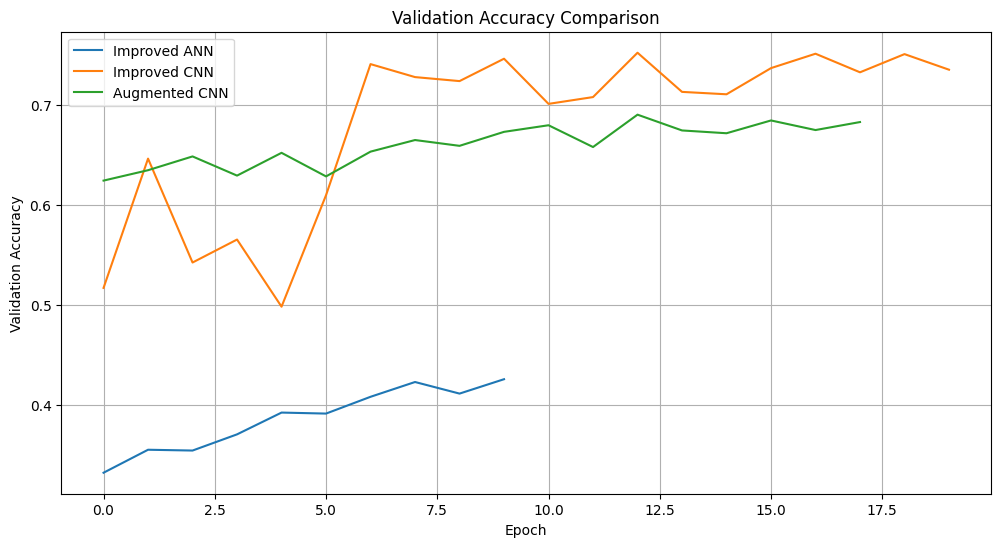

In [51]:
plt.figure(figsize=(12,6))

plt.plot(
    improved_ann_history.history['val_accuracy'],
    label='Improved ANN'
)

plt.plot(
    improved_cnn_history.history['val_accuracy'],
    label='Improved CNN'
)

plt.plot(
    aug_history.history['val_accuracy'],
    label='Augmented CNN'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.show()

# **Final Comparison Table**

In [52]:
final_comparison = pd.DataFrame({
    "Model":[
        "ANN",
        "CNN",
        "Improved ANN",
        "Improved CNN",
        "Augmented CNN"
    ],
    "Test Accuracy":[
        ann_test_acc,
        cnn_test_acc,
        improved_ann_acc,
        improved_cnn_acc,
        aug_test_acc
    ]
})

final_comparison["Test Accuracy"] = (
    final_comparison["Test Accuracy"] * 100
).round(2)

final_comparison

,Model,Test Accuracy
0,ANN,42.08
1,CNN,68.49
2,Improved ANN,43.50
3,Improved CNN,71.65
4,Augmented CNN,68.27


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**